### 第21章 K 均值聚类
- 机器学习模型将数据集中的样本划分为若干个组，每个组称为一个“簇”，这种学习方式称为“聚类”（clustering）
- 聚类是一种无监督学习，它能够将具有相似属性的对象划分到同一个集合（簇）中
- K 均值聚类算法的基本步骤：
    1. 随机选择 K 个样本作为初始的簇中心
    2. 计算每个样本与各个簇中心的距离，将样本划分到最近的簇中
    3. 更新簇中心为每个簇中所有样本的均值，将该平均值作为新的簇中心
    4. 重复步骤 2 和 3，直到簇中心不再发生变化或变化非常小

- 函数 `retval, bestLabels, centers = cv2.kmeans(data, K, bestLabels, criteria, attempts, flags)` 实现 K 均值聚类
    - `retval` 距离值，也称密度值或紧密度，返回每个点到相应中心点距离的平方和
    - `bestLabels` 各个数据点的最终分类标签（索引）
    - `centers` 每个分类的中心点坐标
    - `data` 待处理的数据集合，是 `np.float32` 类型，每个特征放在单独一列
    - `K` 聚类中心的数量
    - `bestLabels` 用来保存每个数据点的最终分类标签，实际调用时设置为 `None`
    - `criteria` 迭代终止条件，是一个包含三个元素的元组：`(type, max_iter, epsilon)`
        - `type` 指定迭代终止的条件，可以是 
            - `cv2.TERM_CRITERIA_EPS` 迭代过程中两次结果之间的最大变化量小于 `epsilon` 时停止迭代
            - `cv2.TERM_CRITERIA_MAX_ITER` 迭代次数超过 `max_iter` 时停止迭代 
            - `cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX` 上述两个条件中任意一个满足时停止迭代
        - `max_iter` 最大迭代次数
        - `epsilon` 迭代过程中两次结果之间的最大变化量（精度阈值）
    - `attempts` 指定该值，可以让算法使用不同的初始值进行多次（attempts）次迭代，以选择最佳结果
    - `flags` 指定算法的实现方式，可选值有
        - `cv2.KMEANS_RANDOM_CENTERS` 随机选择初始中心点
        - `cv2.KMEANS_PP_CENTERS` 选择初始中心点的方式是使用 K 均值++ 方法
        - `cv2.KMEANS_USE_INITIAL_LABELS` 使用用户提供的初始标签；如果attempts值大于1，后续尝试使用随机值或者半随机值作为第一次分类中心点

##### 单特征 K 均值聚类

距离: 6191.437820926309
标签的维度：
 (120, 1)
中心点：
 [[13.691176]
 [38.46154 ]]


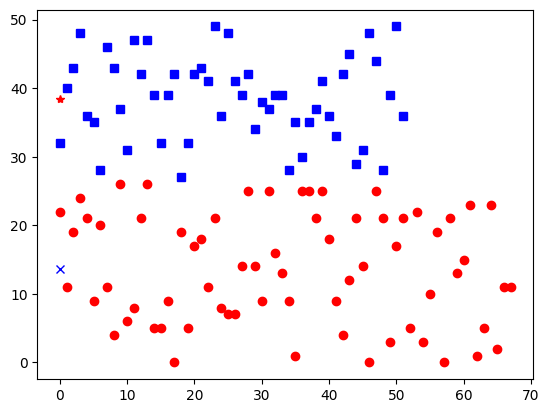

In [6]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# ===================== 1．数据准备=======================
MI = np.random.randint(0, 50, (120, 1))
MI = np.float32(MI)
# ================= 2．使用K均值聚类模块 ==============
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
flags = cv2.KMEANS_RANDOM_CENTERS
retval, bestLabels, centers = cv2.kmeans(MI, 2, None, criteria, 10, flags)
# ================3．打印 =====================
print("距离:", retval)  # 每个点到中心的距离平方和
print("标签的维度：\n", bestLabels.shape)  # 分类标签
print("中心点：\n", centers)  # 每个分类的中心点
# =============== 4．可视化 ======================
XM = MI[bestLabels == 0]
YM = MI[bestLabels == 1]
plt.plot(XM, "ro")  # r表示红色，o表示圆
plt.plot(YM, "bs")  # b表示蓝色，s表示正方形
plt.plot(centers[0], "bx")  # b表示蓝色，X表示星号
plt.plot(centers[1], "r*")  # r表示红色，*表示星号
plt.show()

##### 双特征值 K 均值聚类

距离： 1952.333759188652
标签维度：
 (60, 1)
分类中心点：
 [[ 4.7391305  7.173913 ]
 [14.162163  10.1081085]]


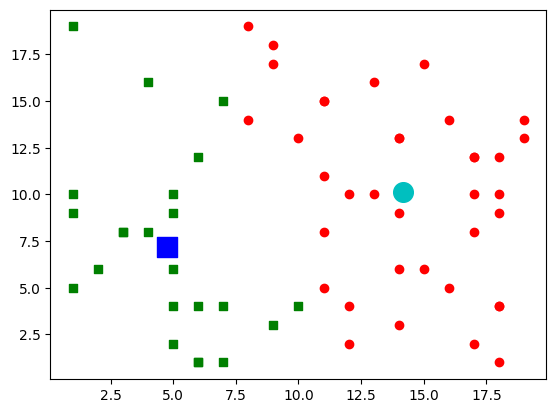

In [10]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# ================ 1．数据准备 ====================
MI = np.random.randint(1, 20, (60, 2))
MI = np.float32(MI)
# ============== 2．使用K均值聚类模块 ===============
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
ret, label, center = cv2.kmeans(MI, 2, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
# ==============3．打印 =====================
print("距离：", ret)
print("标签维度：\n", label.shape)
print("分类中心点：\n", center)
# ==============4．可视化 ====================
XM = MI[label.ravel() == 0] # ravel() 将多维数组降为一维数组，便于索引
YM = MI[label.ravel() == 1]
# 绘制分类结果数据
plt.scatter(XM[:, 0], XM[:, 1], c="g", marker="s")
plt.scatter(YM[:, 0], YM[:, 1], c="r", marker="o")
# 绘制分类数据的中心点
plt.scatter(center[0, 0], center[0, 1], s=200, c="b", marker="s")
plt.scatter(center[1, 0], center[1, 1], s=200, c="c", marker="o")
plt.show()


##### 灰度图像二值化

图像维度： (512, 512, 3)
距离： 544106720.8716774
标签维度：
 (262144, 1)
分类中心点：
 [[ 78.10835  78.10835  78.10835]
 [158.99724 158.99724 158.99724]]


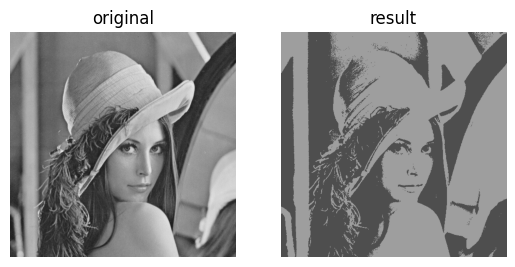

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# =================== 1．图像预处理 =======================
# img = cv2.imread('lenacolor.png')
img = cv2.imread("lena.bmp")
data = img.reshape((-1,3))
data = np.float32(data)
# ================= 2．使用K均值聚类模块 =====================
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 2
ret,label,center = cv2.kmeans(data,K,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)
# =================== 3．打印的实现 ============================
print("图像维度：", img.shape)
print("距离：",ret)
print("标签维度：\n",label.shape)
print("分类中心点：\n",center)
# =============== 4．像素值替换及结果展示 =======================
center = np.uint8(center)
# 像素是 0 → 取 center[0] → [B1,G1,R1]
# 像素是 1 → 取 center[1] → [B2,G2,R2]
res1 = center[label.flatten()]
res2 = res1.reshape((img.shape))

# img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# res2 = cv2.cvtColor(res2, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1,2)
axes[0].imshow(img, cmap="gray")
axes[0].set_title("original")
axes[0].axis("off")
axes[1].imshow(res2, cmap="gray")
axes[1].set_title("result") 
axes[1].axis("off")
plt.show()